# RGB + HSI Data EDA

This notebook helps you inspect the RGB and HSI datasets, compare split balance, visualize sample patches and masks, and render a map of patch locations from GeoTIFF metadata.


In [1]:
from __future__ import annotations

import math
import re
import sys
from collections import Counter
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import tifffile
from PIL import Image
from rasterio.warp import transform_bounds

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

plt.style.use('seaborn-v0_8-whitegrid')
PATCH_RE = re.compile(r'^(?P<year>\d{4})_(?P<site>[A-Z]+)_(?P<tile>\d+)_(?P<east>\d+)_(?P<north>\d+)_image_patch(?P<patch>\d+)\.tif$')


In [2]:
RGB_SPLIT_ROOT = PROJECT_ROOT / 'data' / 'splits' / 'rgb_binary_10pct_balanced'
HSI_SPLIT_ROOT = PROJECT_ROOT / 'data' / 'splits' / 'hsi_binary_20_balanced'
HSI_PREPROCESSED_ROOT = PROJECT_ROOT / 'data' / 'splits' / 'hsi_binary_10pct_balanced'

RGB_EXTS = ('.tif', '.tiff', '.png', '.jpg', '.jpeg')
HSI_EXTS = ('.tif', '.tiff')

print('PROJECT_ROOT =', PROJECT_ROOT)
print('RGB_SPLIT_ROOT =', RGB_SPLIT_ROOT)
print('HSI_SPLIT_ROOT =', HSI_SPLIT_ROOT)
print('HSI_PREPROCESSED_ROOT =', HSI_PREPROCESSED_ROOT)


PROJECT_ROOT = /home/echerif/ironhack/neon_tree_crown_v3
RGB_SPLIT_ROOT = /home/echerif/ironhack/neon_tree_crown_v3/data/splits/rgb_binary_10pct_balanced
HSI_SPLIT_ROOT = /home/echerif/ironhack/neon_tree_crown_v3/data/splits/hsi_binary_20_balanced
HSI_PREPROCESSED_ROOT = /home/echerif/ironhack/neon_tree_crown_v3/data/splits/hsi_binary_10pct_balanced


In [21]:
def parse_patch_name(path: Path) -> dict:
    stem = path.stem
    prefix, patch_part = (stem.split('_image_patch', 1) + [''])[:2] if '_image_patch' in stem else (stem, '')
    parts = prefix.split('_')

    year = int(parts[0]) if len(parts) > 0 and parts[0].isdigit() else None
    site = parts[1] if len(parts) > 1 else 'UNKNOWN'
    tile = int(parts[2]) if len(parts) > 2 and parts[2].isdigit() else None
    east = int(parts[3]) if len(parts) > 3 and parts[3].isdigit() else None
    north = int(parts[4]) if len(parts) > 4 and parts[4].isdigit() else None
    patch_idx = int(patch_part) if patch_part.isdigit() else None

    return {
        'name': path.name,
        'year': year,
        'site': site,
        'tile': tile,
        'east': east,
        'north': north,
        'patch_idx': patch_idx,
        'group': prefix,
    }

def list_split_images(root: Path, exts) -> pd.DataFrame:
    rows = []
    for split in ('train', 'val', 'test'):
        img_dir = root / split / 'img'
        if not img_dir.exists():
            continue
        for path in sorted(img_dir.glob('*')):
            if path.suffix.lower() not in exts:
                continue
            row = parse_patch_name(path)
            row['split'] = split
            row['path'] = path
            rows.append(row)
    return pd.DataFrame(rows)

def list_split_labels(root: Path) -> dict[tuple[str, str], Path]:
    labels = {}
    for split in ('train', 'val', 'test'):
        lbl_dir = root / split / 'labels'
        if not lbl_dir.exists():
            continue
        for path in sorted(lbl_dir.glob('*')):
            labels[(split, path.name)] = path
    return labels

def summarize_split(df: pd.DataFrame, title: str) -> None:
    if df.empty:
        print(f'{title}: no files found')
        return
    display(df.groupby('split').size().rename('count').to_frame())
    display(df.groupby(['year', 'site', 'split']).size().rename('count').reset_index())

def read_rgb_preview(path: Path) -> np.ndarray:
    if path.suffix.lower() in ('.tif', '.tiff'):
        arr = tifffile.imread(path)
        if arr.ndim == 2:
            arr = np.stack([arr] * 3, axis=-1)
        if arr.ndim == 3 and arr.shape[0] in {3, 4} and arr.shape[-1] not in {3, 4}:
            arr = np.moveaxis(arr, 0, -1)
        if arr.shape[-1] > 3:
            arr = arr[..., :3]
        arr = np.clip(arr, 0, 255).astype(np.uint8)
        return arr
    return np.array(Image.open(path).convert('RGB'))

def read_mask(path: Path) -> np.ndarray:
    arr = tifffile.imread(path).astype(np.float32)
    return (arr > 0).astype(np.uint8)

def _hsi_to_hwc(cube: np.ndarray) -> np.ndarray:
    if cube.ndim != 3:
        raise ValueError(f'Expected HSI cube with 3 dims, got {cube.shape}')
    # Prefer the notebook's original convention: spectral axis first (B, H, W).
    # Fall back to channels-last if the last axis is clearly spectral.
    if cube.shape[0] > 16 and cube.shape[1] <= 256 and cube.shape[2] <= 256:
        return np.moveaxis(cube, 0, -1)
    if cube.shape[-1] > 16 and cube.shape[0] <= 256 and cube.shape[1] <= 256:
        return cube
    raise ValueError(f'Cannot infer spectral axis for cube with shape {cube.shape}')

def hsi_false_color(path: Path) -> np.ndarray:
    cube = tifffile.imread(path).astype(np.float32)
    cube_hwc = _hsi_to_hwc(cube)

    n_bands = cube_hwc.shape[-1]
    wavelengths = np.linspace(400, 2450, n_bands)
    nir = int(np.argmin(np.abs(wavelengths - 850)))
    red = int(np.argmin(np.abs(wavelengths - 670)))
    green = int(np.argmin(np.abs(wavelengths - 550)))

    rgb = cube_hwc[..., [nir, red, green]]
    rgb = np.nan_to_num(rgb, nan=0.0, posinf=0.0, neginf=0.0)

    lo, hi = np.percentile(rgb, (2, 98))
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)

def hsi_true_color(path: Path) -> np.ndarray:
    cube = tifffile.imread(path).astype(np.float32)
    cube_hwc = _hsi_to_hwc(cube)

    n_bands = cube_hwc.shape[-1]
    wavelengths = np.linspace(400, 2450, n_bands)
    red = int(np.argmin(np.abs(wavelengths - 650)))
    green = int(np.argmin(np.abs(wavelengths - 550)))
    blue = int(np.argmin(np.abs(wavelengths - 450)))

    rgb = cube_hwc[..., [red, green, blue]]
    rgb = np.nan_to_num(rgb, nan=0.0, posinf=0.0, neginf=0.0)

    lo, hi = np.percentile(rgb, (2, 98))
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)

def mask_overlay(image: np.ndarray, mask: np.ndarray, color=(1.0, 0.3, 0.0), alpha: float = 0.45) -> np.ndarray:
    base = image.astype(np.float32).copy()
    if base.max() > 1.0:
        base = base / 255.0
    overlay = base.copy()
    mask_bool = mask.astype(bool)
    overlay[mask_bool] = (1 - alpha) * overlay[mask_bool] + alpha * np.array(color, dtype=np.float32)
    return np.clip(overlay, 0, 1)

def mask_coverage(mask: np.ndarray) -> float:
    return float(mask.mean())

def sample_dataframe(df: pd.DataFrame, n: int = 6, seed: int = 42) -> pd.DataFrame:
    if df.empty:
        return df
    return df.sample(min(n, len(df)), random_state=seed).sort_values(['split', 'year', 'site'])

def geotiff_center(path: Path):
    try:
        with rasterio.open(path) as src:
            if src.crs is None:
                return None
            west, south, east, north = transform_bounds(src.crs, 'EPSG:4326', *src.bounds, densify_pts=21)
            return {
                'lat': (south + north) / 2,
                'lon': (west + east) / 2,
                'crs': str(src.crs),
            }
    except Exception:
        return None

def build_location_frame(df: pd.DataFrame, sample_per_split: int = 150) -> pd.DataFrame:
    rows = []
    if df.empty:
        return pd.DataFrame()
    for split, part in df.groupby('split'):
        subset = part.sample(min(sample_per_split, len(part)), random_state=42)
        for _, row in subset.iterrows():
            center = geotiff_center(row['path'])
            if center is None:
                continue
            rows.append({**row.to_dict(), **center})
    return pd.DataFrame(rows)





## 1. Inventory


In [22]:
rgb_df = list_split_images(RGB_SPLIT_ROOT, RGB_EXTS)
hsi_df = list_split_images(HSI_PREPROCESSED_ROOT if HSI_PREPROCESSED_ROOT.exists() else HSI_SPLIT_ROOT, HSI_EXTS)
rgb_labels = list_split_labels(RGB_SPLIT_ROOT)
hsi_labels = list_split_labels(HSI_PREPROCESSED_ROOT if HSI_PREPROCESSED_ROOT.exists() else HSI_SPLIT_ROOT)

print('RGB files:', len(rgb_df))
print('HSI files:', len(hsi_df))


RGB files: 2202
HSI files: 2107


In [23]:
summarize_split(rgb_df, 'RGB split summary')
summarize_split(hsi_df, 'HSI split summary')

,count
split,
train,1981
val,221


,year,site,split,count
0,2018,BART,train,5
1,2018,BART,val,1
2,2018,HARV,train,17
3,2018,HARV,val,2
4,2018,JERC,train,9
5,2018,JERC,val,1
6,2018,MLBS,train,45
7,2018,MLBS,val,5
8,2018,NIWO,train,76
9,2018,NIWO,val,8


,count
split,
train,1895
val,212


,year,site,split,count
0,2018,BART,train,5
1,2018,BART,val,1
2,2018,HARV,train,16
3,2018,HARV,val,2
4,2018,JERC,train,9
5,2018,JERC,val,1
6,2018,MLBS,train,45
7,2018,MLBS,val,5
8,2018,NIWO,train,76
9,2018,NIWO,val,8


## 2. RGB EDA


In [33]:
# rgb_sample = sample_dataframe(rgb_df, n=6)
# fig, axes = plt.subplots(len(rgb_sample), 2, figsize=(10, 4 * len(rgb_sample)))
# if len(rgb_sample) == 1:
#     axes = np.array([axes])
# for ax_row, (_, row) in zip(axes, rgb_sample.iterrows()):
#     img = read_rgb_preview(row['path'])
#     mask = read_mask(rgb_labels[(row['split'], row['name'])])
#     ax_row[0].imshow(img)
#     ax_row[0].set_title(f"RGB | {row['split']} | {row['site']} | {row['name']}")
#     ax_row[1].imshow(mask, cmap='Greens')
#     ax_row[1].set_title(f"Mask coverage = {mask_coverage(mask):.3f}")
#     for ax in ax_row:
#         ax.axis('off')
# plt.tight_layout()


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
train,1981.0,0.187992,0.172880,0.000117,0.054570,0.141016,0.269932,0.853701
val,221.0,0.195408,0.170578,0.002109,0.069082,0.142441,0.284473,0.781660


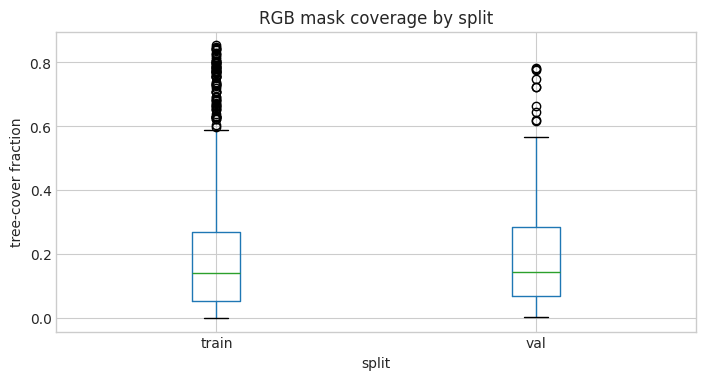

In [7]:
rgb_cov = []
for _, row in rgb_df.iterrows():
    key = (row['split'], row['name'])
    if key not in rgb_labels:
        continue
    cov = mask_coverage(read_mask(rgb_labels[key]))
    rgb_cov.append({'split': row['split'], 'year': row['year'], 'site': row['site'], 'coverage': cov})
rgb_cov_df = pd.DataFrame(rgb_cov)
display(rgb_cov_df.groupby('split')['coverage'].describe())
rgb_cov_df.boxplot(column='coverage', by='split', figsize=(8, 4))
plt.suptitle('')
plt.title('RGB mask coverage by split')
plt.ylabel('tree-cover fraction')
plt.show()


## 3. HSI EDA


In [25]:
path = hsi_df['path'][0]

In [26]:
cube = tifffile.imread(path).astype(np.float32)
if cube.ndim != 3:
    raise ValueError(f'Expected HSI cube with 3 dims, got {cube.shape}')
n_bands = cube.shape[0]
wavelengths = np.linspace(400, 2450, n_bands)
nir = int(np.argmin(np.abs(wavelengths - 850)))
red = int(np.argmin(np.abs(wavelengths - 670)))
green = int(np.argmin(np.abs(wavelengths - 550)))
rgb = np.stack([cube[nir], cube[red], cube[green]], axis=-1)
lo, hi = np.percentile(rgb, (2, 98))
# return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)

In [27]:
cube.shape

(32, 32, 426)

In [32]:
# hsi_sample = sample_dataframe(hsi_df, n=6)
# fig, axes = plt.subplots(len(hsi_sample), 2, figsize=(10, 4 * len(hsi_sample)))
# if len(hsi_sample) == 1:
#     axes = np.array([axes])
# for ax_row, (_, row) in zip(axes, hsi_sample.iterrows()):
#     fc = hsi_false_color(row['path'])
#     mask = read_mask(hsi_labels[(row['split'], row['name'])])
#     ax_row[0].imshow(fc)
#     ax_row[0].set_title(f"HSI false color | {row['split']} | {row['site']}")
#     ax_row[1].imshow(mask, cmap='Greens')
#     ax_row[1].set_title(f"Mask coverage = {mask_coverage(mask):.3f}")
#     for ax in ax_row:
#         ax.axis('off')
# plt.tight_layout()


## 4b. Matched RGB vs HSI examples

Show the same 3 patch names across RGB and HSI horizontally for quick visual comparison.


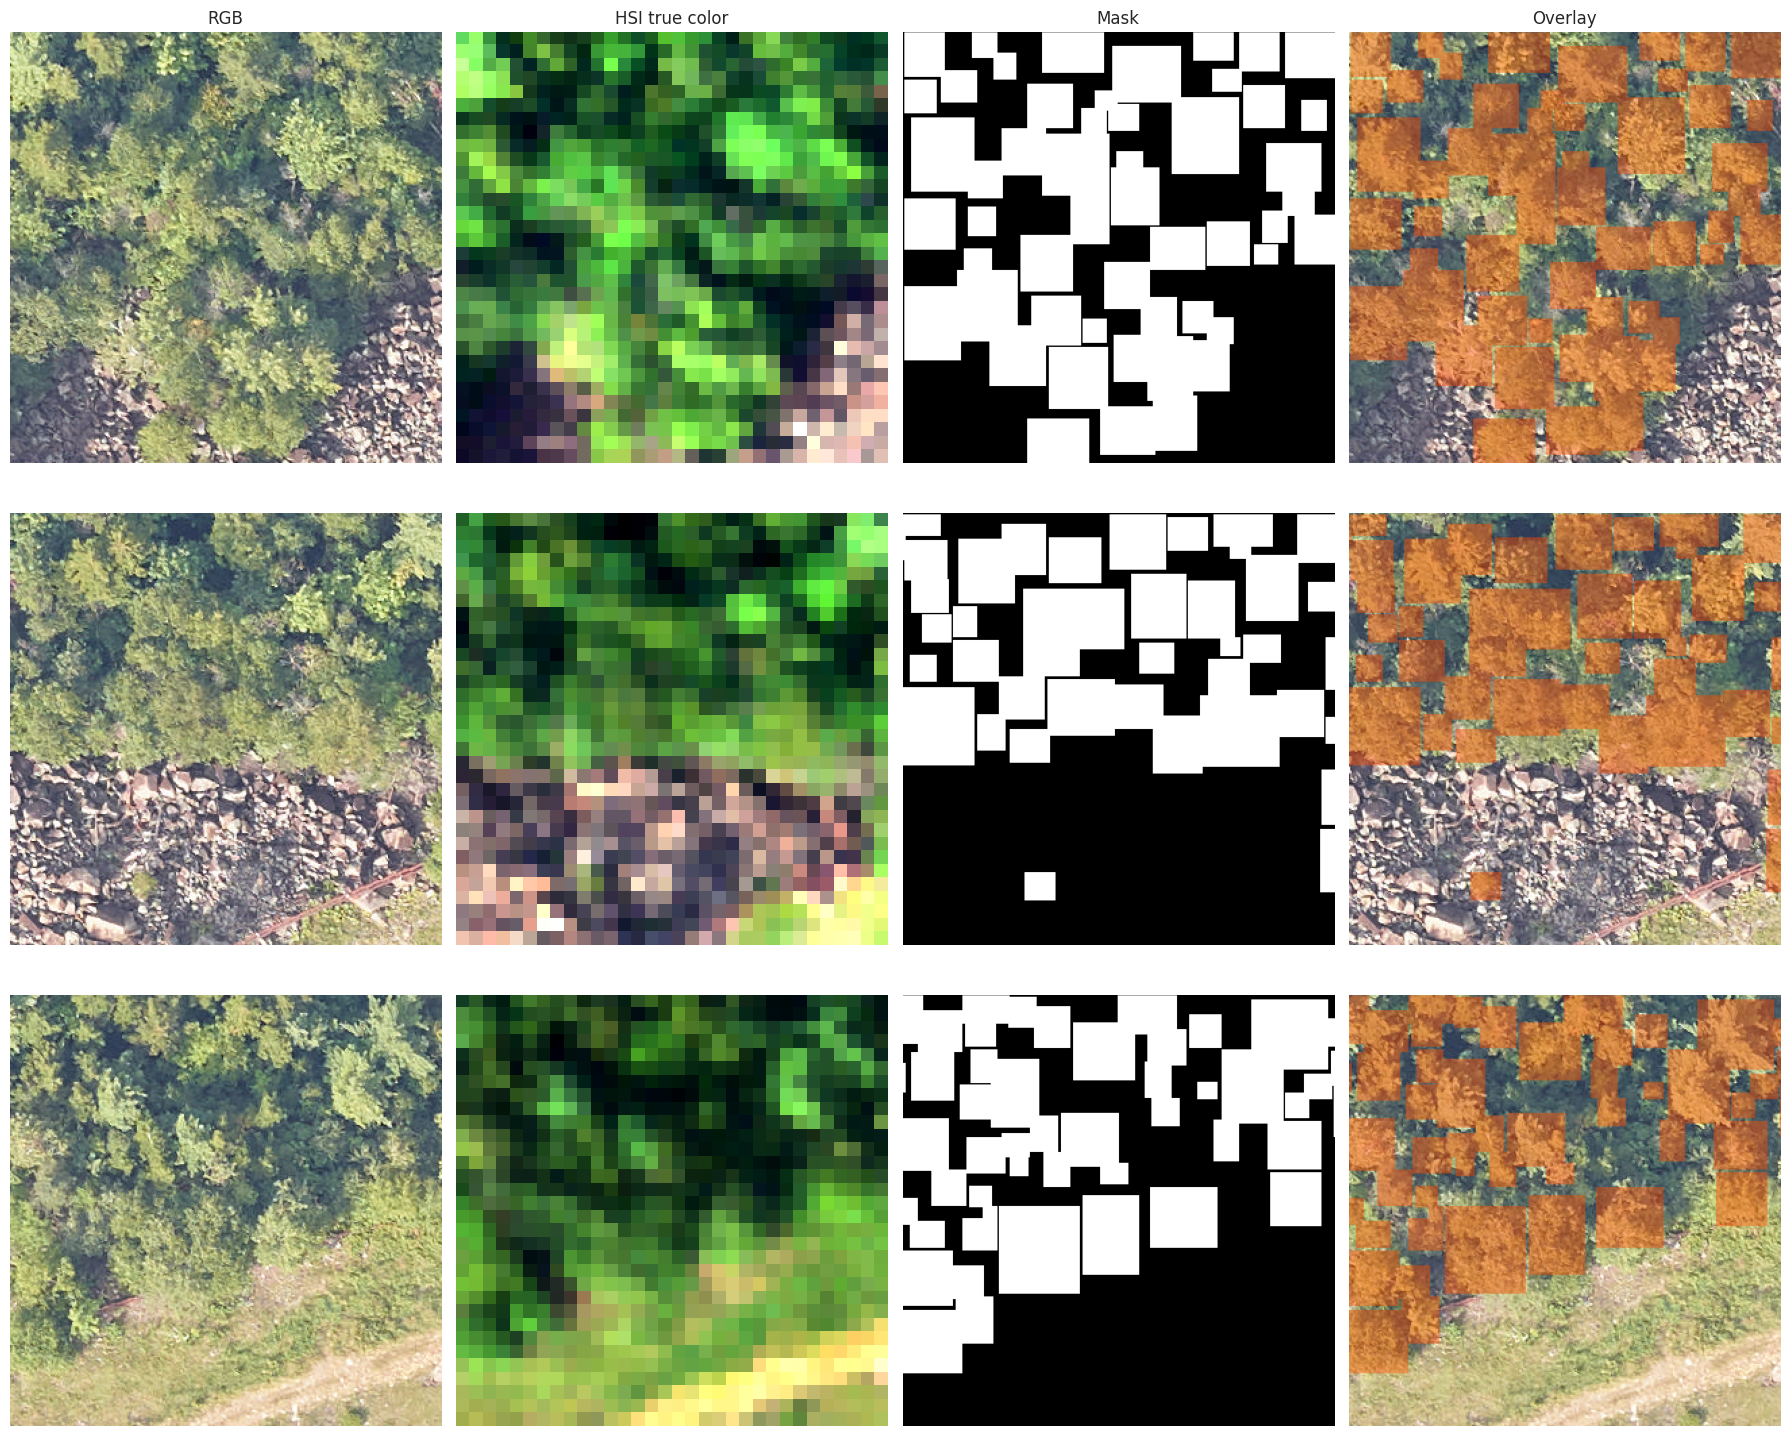

In [30]:
rgb_lookup = {(row['split'], row['name']): row['path'] for _, row in rgb_df.iterrows()}
hsi_lookup = {(row['split'], row['name']): row['path'] for _, row in hsi_df.iterrows()}
common_keys = sorted(set(rgb_lookup) & set(hsi_lookup))

if common_keys:
    chosen_keys = common_keys[:3]
    fig, axes = plt.subplots(len(chosen_keys), 4, figsize=(18, 5 * len(chosen_keys)))
    if len(chosen_keys) == 1:
        axes = np.array([axes])

    col_titles = ['RGB', 'HSI true color', 'Mask', 'Overlay']
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title)

    for row_idx, key in enumerate(chosen_keys):
        split, name = key
        rgb_img = read_rgb_preview(rgb_lookup[key])
        hsi_img = hsi_true_color(hsi_lookup[key])
        mask_path = rgb_labels.get(key) or hsi_labels.get(key)
        mask = read_mask(mask_path) if mask_path is not None else None

        axes[row_idx, 0].imshow(rgb_img)
        axes[row_idx, 0].axis('off')

        axes[row_idx, 1].imshow(hsi_img)
        axes[row_idx, 1].axis('off')

        if mask is not None:
            axes[row_idx, 2].imshow(mask, cmap='gray')
            axes[row_idx, 2].axis('off')

            overlay = mask_overlay(rgb_img, mask)
            axes[row_idx, 3].imshow(overlay)
            axes[row_idx, 3].axis('off')
        else:
            axes[row_idx, 2].text(0.5, 0.5, 'Mask not found', ha='center', va='center')
            axes[row_idx, 2].axis('off')
            axes[row_idx, 3].imshow(hsi_img)
            axes[row_idx, 3].axis('off')

        axes[row_idx, 0].set_ylabel(f"{split}\n{name}", rotation=0, labelpad=60, va='center')

    plt.tight_layout()
else:
    print('No shared RGB/HSI patch names found to compare.')



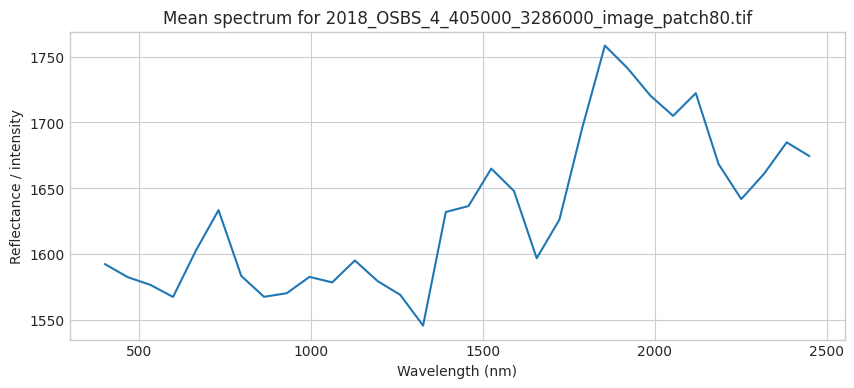

In [34]:
if not hsi_sample.empty:
    sample_path = hsi_sample.iloc[0]['path']
    cube = tifffile.imread(sample_path).astype(np.float32)
    n_bands = cube.shape[0]
    wavelengths = np.linspace(400, 2450, n_bands)
    mean_spectrum = cube.mean(axis=(1, 2))
    plt.figure(figsize=(10, 4))
    plt.plot(wavelengths, mean_spectrum)
    plt.title(f'Mean spectrum for {sample_path.name}')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Reflectance / intensity')
    plt.show()


## 4. Split fairness


In [15]:
def show_group_counts(df: pd.DataFrame, name: str):
    if df.empty:
        print(f'{name}: no files')
        return
    counts = df.groupby(['year', 'site', 'split']).size().rename('count').reset_index()
    pivot = counts.pivot_table(index=['year', 'site'], columns='split', values='count', fill_value=0)
    display(pivot)

show_group_counts(rgb_df, 'RGB')
show_group_counts(hsi_df, 'HSI')


split       train    val
year site               
2018 BART     5.0    1.0
     HARV    17.0    2.0
     JERC     9.0    1.0
     MLBS    45.0    5.0
     NIWO    76.0    8.0
     OSBS   135.0   15.0
     SJER  1322.0  147.0
     TEAK   291.0   32.0
2019 DELA    14.0    2.0
     LENO    18.0    2.0
     OSBS    36.0    4.0
     SJER    13.0    1.0
     TOOL     0.0    1.0

split       train    val
year site               
2018 BART     5.0    1.0
     HARV    16.0    2.0
     JERC     9.0    1.0
     MLBS    45.0    5.0
     NIWO    76.0    8.0
     OSBS   121.0   13.0
     SJER  1258.0  140.0
     TEAK   291.0   32.0
2019 DELA    14.0    2.0
     LENO    18.0    2.0
     OSBS    35.0    4.0
     SJER     7.0    1.0
     TOOL     0.0    1.0

## 5. Geospatial map of patch origins


In [16]:
loc_df = build_location_frame(pd.concat([rgb_df.assign(modality='RGB'), hsi_df.assign(modality='HSI')], ignore_index=True)) if (not rgb_df.empty or not hsi_df.empty) else pd.DataFrame()

if not loc_df.empty:
    site_summary = (
        loc_df.groupby(['site', 'year'], dropna=False)
        .agg(
            lat=('lat', 'mean'),
            lon=('lon', 'mean'),
            n_images=('name', 'count'),
            rgb_images=('modality', lambda s: int((s == 'RGB').sum())),
            hsi_images=('modality', lambda s: int((s == 'HSI').sum())),
            train_images=('split', lambda s: int((s == 'train').sum())),
            val_images=('split', lambda s: int((s == 'val').sum())),
            test_images=('split', lambda s: int((s == 'test').sum())),
        )
        .reset_index()
        .sort_values(['year', 'site'])
    )
    display(site_summary)
else:
    site_summary = pd.DataFrame()
    print('No geospatial metadata available for site summary.')

,site,year,lat,lon,n_images,rgb_images,hsi_images,train_images,val_images,test_images
0,BART,2018,44.074488,-71.222067,1,1,0,0,1,0
2,HARV,2018,42.405430,-72.158511,2,1,1,2,0,0
3,JERC,2018,31.174337,-84.452419,1,1,0,0,1,0
5,MLBS,2018,37.409900,-80.532126,6,4,2,2,4,0
6,NIWO,2018,39.989867,-105.584452,8,5,3,5,3,0
7,OSBS,2018,29.704413,-81.976099,22,15,7,9,13,0
9,SJER,2018,37.090456,-119.712273,203,106,97,106,97,0
11,TEAK,2018,36.980609,-119.073361,42,21,21,19,23,0
1,DELA,2019,32.549314,-87.818024,2,1,1,0,2,0
4,LENO,2019,31.840248,-88.228126,3,0,3,2,1,0


In [17]:
if not site_summary.empty:
    center = [site_summary['lat'].mean(), site_summary['lon'].mean()]
    fmap = folium.Map(location=center, zoom_start=5, control_scale=True)

    count_values = site_summary['n_images'].astype(float)
    q1 = count_values.quantile(0.25)
    q2 = count_values.quantile(0.50)
    q3 = count_values.quantile(0.75)

    def color_for_count(n: float) -> str:
        if n <= q1:
            return '#2c7bb6'
        if n <= q2:
            return '#abd9e9'
        if n <= q3:
            return '#fdae61'
        return '#d7191c'

    for _, row in site_summary.iterrows():
        color = color_for_count(row['n_images'])
        radius = 6 + min(18, row['n_images'] ** 0.5)
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=radius,
            color=color,
            weight=2,
            fill=True,
            fill_color=color,
            fill_opacity=0.75,
            tooltip=(
                f"{int(row['year']) if pd.notna(row['year']) else 'Unknown'} | {row['site']}<br>"
                f"Images: {int(row['n_images'])}<br>"
                f"RGB: {int(row['rgb_images'])} | HSI: {int(row['hsi_images'])}<br>"
                f"Train: {int(row['train_images'])} | Val: {int(row['val_images'])} | Test: {int(row['test_images'])}"
            ),
        ).add_to(fmap)

    legend_html = f"""
    <div style="position: fixed; bottom: 40px; left: 40px; z-index: 9999; background: white;
                border: 2px solid #444; border-radius: 8px; padding: 10px 12px; font-size: 13px;
                box-shadow: 0 1px 4px rgba(0,0,0,0.25);">
      <div style="font-weight: 700; margin-bottom: 6px;">Images per site</div>
      <div><span style="display:inline-block;width:12px;height:12px;background:#2c7bb6;margin-right:6px;"></span>&le; {q1:.0f}</div>
      <div><span style="display:inline-block;width:12px;height:12px;background:#abd9e9;margin-right:6px;"></span>{q1:.0f} to {q2:.0f}</div>
      <div><span style="display:inline-block;width:12px;height:12px;background:#fdae61;margin-right:6px;"></span>{q2:.0f} to {q3:.0f}</div>
      <div><span style="display:inline-block;width:12px;height:12px;background:#d7191c;margin-right:6px;"></span>&gt; {q3:.0f}</div>
    </div>
    """
    fmap.get_root().html.add_child(folium.Element(legend_html))
    fmap
else:
    print('No GeoTIFF metadata with CRS found for mapping.')



In [18]:
fmap